# LOAD LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
import math
import json
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import shap
from scipy.stats import linregress
from diive.core.io.files import load_parquet
from datetime import datetime

# CONFIGURATION

In [2]:
START_DATE, END_DATE = '2023-11-08', '2025-06-05'
TARGET_FLUX = 'FN2O'
N_FOLDS = 10
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
CROSSVAL_SPLIT = 'time_blocks_eliza' # options: 'shuffle' or 'kfold' or 'custom_time_blocks' or 'time_blocks_eliza'
PARCEL_CERTAIN = True
LOG_TRANSFORM = True
ADD_ID = True
UNDERSAMPLE = True
ADD_TRT = True

# LOAD DATA

In [3]:
data_main = fluxes = load_parquet(filepath=r"82.1.1_GapFillingDataset.parquet")
data_main = data_main.loc[START_DATE:END_DATE].copy()
maindf = data_main.copy() # keep a copy for later

# Add an id column to account for the proximity of values as the timestamp is continuous without gaps
if ADD_ID:
    data_main['id'] = range(0, len(data_main))

# Add trt variable
if ADD_TRT:
    data_main['trt'] = data_main['parcel'].map({'A': 0, 'B': 1}).fillna(0.5)

data_main

Loaded .parquet file 82.1.1_GapFillingDataset.parquet (0.507 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,NEE_L3.3_CUT_50_QCF,FN2O_L3.3_CUT_50_QCF,FCH4_L3.3_CUT_50_QCF,NEE_L3.3_CUT_50_QCF0,FN2O_L3.3_CUT_50_QCF0,FCH4_L3.3_CUT_50_QCF0,parcel,parcel_certainty,SW_IN_POT,NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelA_certain,NEE_L3.3_CUT_50_QCF_gfXGBoost_parcelB_certain,RECO_NT_CUT_50_gfXG_parcelA_certain,GPP_NT_CUT_50_gfXG_parcelA_certain,RECO_NT_CUT_50_gfXG_parcelB_certain,GPP_NT_CUT_50_gfXG_parcelB_certain,...,RECO_NT_CUT_50_gfXG_certain_lag6h_roll9hmean,RECO_NT_CUT_50_gfXG_certain_lag9h_roll3hmean,RECO_NT_CUT_50_gfXG_certain_lag9h_roll6hmean,RECO_NT_CUT_50_gfXG_certain_lag9h_roll9hmean,GPP_NT_CUT_50_gfXG_certain_lag3h_roll3hsum,GPP_NT_CUT_50_gfXG_certain_lag3h_roll6hsum,GPP_NT_CUT_50_gfXG_certain_lag3h_roll9hsum,GPP_NT_CUT_50_gfXG_certain_lag6h_roll3hsum,GPP_NT_CUT_50_gfXG_certain_lag6h_roll6hsum,GPP_NT_CUT_50_gfXG_certain_lag6h_roll9hsum,GPP_NT_CUT_50_gfXG_certain_lag9h_roll3hsum,GPP_NT_CUT_50_gfXG_certain_lag9h_roll6hsum,GPP_NT_CUT_50_gfXG_certain_lag9h_roll9hsum,id,trt
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:15:00,NaN,-0.111997,-3.231648,NaN,NaN,-3.231648,B,certain,0.0,3.083104,3.083104,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1.0
2023-11-08 00:45:00,NaN,0.100302,NaN,NaN,0.100302,NaN,B,certain,0.0,2.952496,2.952496,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1.0
2023-11-08 01:15:00,NaN,0.239428,NaN,NaN,0.239428,NaN,B,certain,0.0,2.789075,2.789075,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1.0
2023-11-08 01:45:00,NaN,-0.184917,6.746138,NaN,NaN,NaN,B,certain,0.0,2.603564,2.603564,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,1.0
2023-11-08 02:15:00,NaN,0.358358,3.168362,NaN,0.358358,3.168362,B,certain,0.0,2.439780,2.439780,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-05 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,7.690165,7.690165,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27643,0.5
2025-06-05 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,7.673741,7.673741,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27644,0.5
2025-06-05 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,8.166399,8.166399,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27645,0.5


In [4]:
TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_QCF0'
print(f'The target variable is {TARGET}')

mean_nan_size = (
    data_main[TARGET]
    .isna()
    .ne(data_main[TARGET].isna().shift())
    .cumsum()
    .where(data_main[TARGET].isna())
    .dropna()
    .value_counts()
    .mean()
)
print("\nMean size of consecutive NaNs in the target variable:", mean_nan_size)

# Remove NAs of the target
data = data_main[data_main[TARGET].notna()].copy()

# Keep only data where we are sure about parcel attribution
if PARCEL_CERTAIN:
    data = data[data['parcel_certainty'] == 'certain'].copy()
    print('\nKeeping only data when we are highly confident on the parcel attribution')

The target variable is FN2O_L3.3_CUT_50_QCF0

Mean size of consecutive NaNs in the target variable: 4.616

Keeping only data when we are highly confident on the parcel attribution


# SELECT FEATURES

In [5]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

# selected_features = [
# 'timesince_soil_preparation',
# 'n_decay_timed',
# 'timesince_fert',
# #'wfps_0.05_gfXG_lag9h',
# 'wfps_0.05_gfXG_roll3hmean',
# 'ts_0.3_gfXG_lag6h_roll9hmean',
# 'GPP_NT_CUT_50_gfXG_certain_roll3hsum'
# ]

# Add trt variable
if ADD_TRT:
    selected_features = selected_features + ['trt']

# Keep only the best feature set
data = data[selected_features + [TARGET]].copy()

data

,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,wfps_0.15_gfXG_lag3h,wfps_0.05_gfXG_roll3hmean,ts_0.3_gfXG_lag6h_roll9hmean,ts_0.3_gfXG_lag9h_roll9hmean,wfps_0.05_gfXG_lag3h_roll9hmean,wfps_0.15_gfXG_lag3h_roll3hmean,wfps_0.15_gfXG_lag3h_roll9hmean,wfps_0.15_gfXG_lag6h_roll3hmean,wfps_0.15_gfXG_lag9h_roll9hmean,n_decay_linear,n_decay_lognormal,n_decay_timed,LAI,can_height,RECO_NT_CUT_50_gfXG_certain_roll3hmean,id,trt,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 00:45:00,42.760131,21.0,22.0,21.0,55.097470,46.457919,11.147678,11.216927,46.399971,55.348721,55.255903,55.182002,55.268951,0.0,0.983564,29.0,0.300704,5.004376,NaN,1,1.0,0.100302
2023-11-08 01:15:00,43.003837,21.0,22.0,21.0,54.952462,46.203886,11.119251,11.189918,46.504865,55.263975,55.240506,55.233626,55.264551,0.0,0.980476,29.0,0.300709,5.004405,NaN,2,1.0,0.239428
2023-11-08 02:15:00,42.971042,21.0,22.0,21.0,55.126747,45.930307,11.073098,11.172378,46.663317,55.122999,55.214027,55.352650,55.244826,0.0,0.974334,29.0,0.300718,5.004462,NaN,4,1.0,0.358358
2023-11-08 03:15:00,43.030472,21.0,22.0,21.0,55.128997,45.870280,11.029898,11.148739,46.752712,55.063659,55.201180,55.380559,55.238288,0.0,0.968238,29.0,0.300727,5.004519,NaN,6,1.0,0.070120
2023-11-08 04:15:00,43.440951,21.0,22.0,21.0,55.314056,45.867461,11.016731,11.119251,46.823286,55.147186,55.214929,55.263975,55.247042,0.0,0.962185,29.0,0.300737,5.004576,NaN,8,1.0,-0.545573
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 21:15:00,45.197942,60.0,23.0,60.0,49.830190,47.838889,16.984228,17.079784,48.221358,49.838620,49.988520,49.966514,50.266203,0.0,0.000000,0.0,4.385766,39.048051,NaN,27594,1.0,0.282174
2025-06-04 21:45:00,45.159003,60.0,23.0,60.0,49.829483,47.840280,16.980679,17.054537,48.172950,49.832333,49.966284,49.936147,50.247451,0.0,0.000000,0.0,4.389574,39.079782,NaN,27595,1.0,0.524032
2025-06-04 22:45:00,45.105104,60.0,23.0,60.0,49.777009,47.842013,16.985123,17.017191,48.078034,49.817767,49.924215,49.887644,50.203644,0.0,0.000000,0.0,4.397189,39.143246,NaN,27597,1.0,-0.069384


# SELECT MODEL

In [6]:
# Load hyperparameters from JSON file
path = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(path, "r") as file:
    hyperparams = json.load(file)

# Print loaded hyperparameters (optional)
print("Loaded Hyperparameters:", hyperparams)

model = RandomForestRegressor(**hyperparams, random_state=42, n_jobs=-1, early_stopping_rounds=10, eval_metric="rmse") if MODEL_TYPE == 'RandomForest' else XGBRegressor(**hyperparams, random_state=42, n_jobs=-1)

Loaded Hyperparameters: {'colsample_bytree': 0.4, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 10, 'min_child_weight': 5, 'n_estimators': 500, 'subsample': 1}


# IMBALANCE HANDLING

## UNDER SAMPLING

Undersampling target data below: 0.36431846240000004


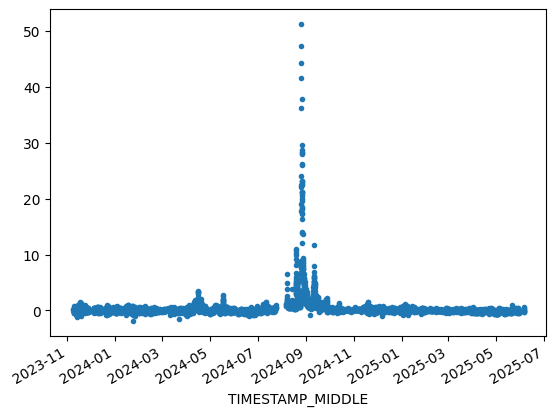

In [7]:
if UNDERSAMPLE:
    quantile_cutoff = 0.8
    cutoff_value = data[TARGET].quantile(quantile_cutoff)
    print(f'Undersampling target data below: {cutoff_value}')
    # Split and undersample
    upper = data[data[TARGET] > cutoff_value]
    lower = data[data[TARGET] <= cutoff_value]
    # Undersample
    lower_sampled = lower.sample(frac=0.5, random_state=42)
    # Combine
    data = pd.concat([upper, lower_sampled]).sample(frac=1, random_state=42)
    # Resort data
    data = data.sort_index().reset_index(drop=False)  # keep the timestamp as a column
    data = data.set_index('TIMESTAMP_MIDDLE')    # and set it back as index if needed
    # Plot
    data[TARGET].plot(x_compat=True, style='.');

## LOG TRANSFORMATION

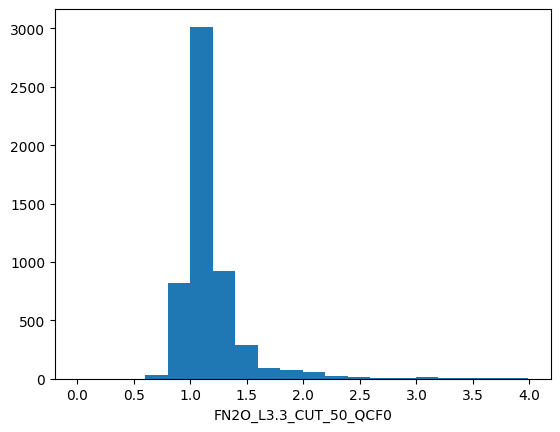

,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,wfps_0.15_gfXG_lag3h,wfps_0.05_gfXG_roll3hmean,ts_0.3_gfXG_lag6h_roll9hmean,ts_0.3_gfXG_lag9h_roll9hmean,wfps_0.05_gfXG_lag3h_roll9hmean,wfps_0.15_gfXG_lag3h_roll3hmean,wfps_0.15_gfXG_lag3h_roll9hmean,wfps_0.15_gfXG_lag6h_roll3hmean,wfps_0.15_gfXG_lag9h_roll9hmean,n_decay_linear,n_decay_lognormal,n_decay_timed,LAI,can_height,RECO_NT_CUT_50_gfXG_certain_roll3hmean,id,trt,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,
2023-11-08 11:45:00,43.461967,21.0,22.0,21.0,55.284707,46.104300,10.960438,11.044033,45.943139,55.297368,55.253698,55.237509,55.234225,0.0,0.918162,29.0,0.300809,5.005021,NaN,23,1.0,1.076139
2023-11-08 14:15:00,43.561690,22.0,23.0,22.0,55.197105,45.955445,10.827212,10.973430,46.027595,55.206512,55.243628,55.296567,55.189551,0.0,0.904009,29.0,0.300834,5.005174,NaN,28,1.0,1.164252
2023-11-09 10:15:00,41.055717,22.0,23.0,22.0,55.726383,43.526391,10.170313,10.592453,44.016848,55.784038,55.780921,55.903289,55.510902,0.0,0.799461,29.0,0.301046,5.006481,2.570156,68,1.0,1.280784
2023-11-09 12:15:00,41.265241,22.0,24.0,22.0,55.707137,43.434872,9.768997,10.392970,43.837938,55.710918,55.796991,55.827479,55.663962,0.0,0.789799,29.0,0.301068,5.006620,2.758518,72,1.0,1.101279
2023-11-09 13:15:00,41.653605,23.0,24.0,23.0,55.676908,43.658539,9.617393,10.170313,43.733373,55.681993,55.789773,55.784038,55.704991,0.0,0.785019,29.0,0.301080,5.006690,2.774617,74,1.0,1.025203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-04 20:45:00,45.234460,60.0,23.0,60.0,49.830048,47.843061,16.994444,17.107500,48.267363,49.851285,50.012284,49.997328,50.282860,0.0,0.000000,0.0,4.381958,39.016319,NaN,27593,1.0,1.012076
2025-06-04 21:45:00,45.159003,60.0,23.0,60.0,49.829483,47.840280,16.980679,17.054537,48.172950,49.832333,49.966284,49.936147,50.247451,0.0,0.000000,0.0,4.389574,39.079782,NaN,27595,1.0,1.221820
2025-06-04 22:45:00,45.105104,60.0,23.0,60.0,49.777009,47.842013,16.985123,17.017191,48.078034,49.817767,49.924215,49.887644,50.203644,0.0,0.000000,0.0,4.397189,39.143246,NaN,27597,1.0,1.029599


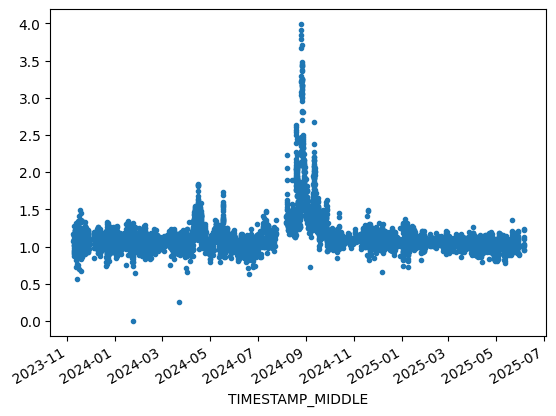

In [8]:
min_value = data[TARGET].min()

def log_transform(x):
    return np.log1p(x - min_value) if min_value < 0 else np.log1p(x)

def inverse_log_transform(x):
    return np.expm1(x) + min_value if min_value < 0 else np.expm1(x)

if LOG_TRANSFORM:
    data[TARGET] = log_transform(data[TARGET])

# Show histogram of TARGET
plt.hist(data[TARGET], bins=20)
plt.xlabel(TARGET)
plt.show()

# Show timeseries
data[TARGET].plot(x_compat=True, style='.');

data

# CROSS-VAL SPLITS

Using stratified approach based on the target variable

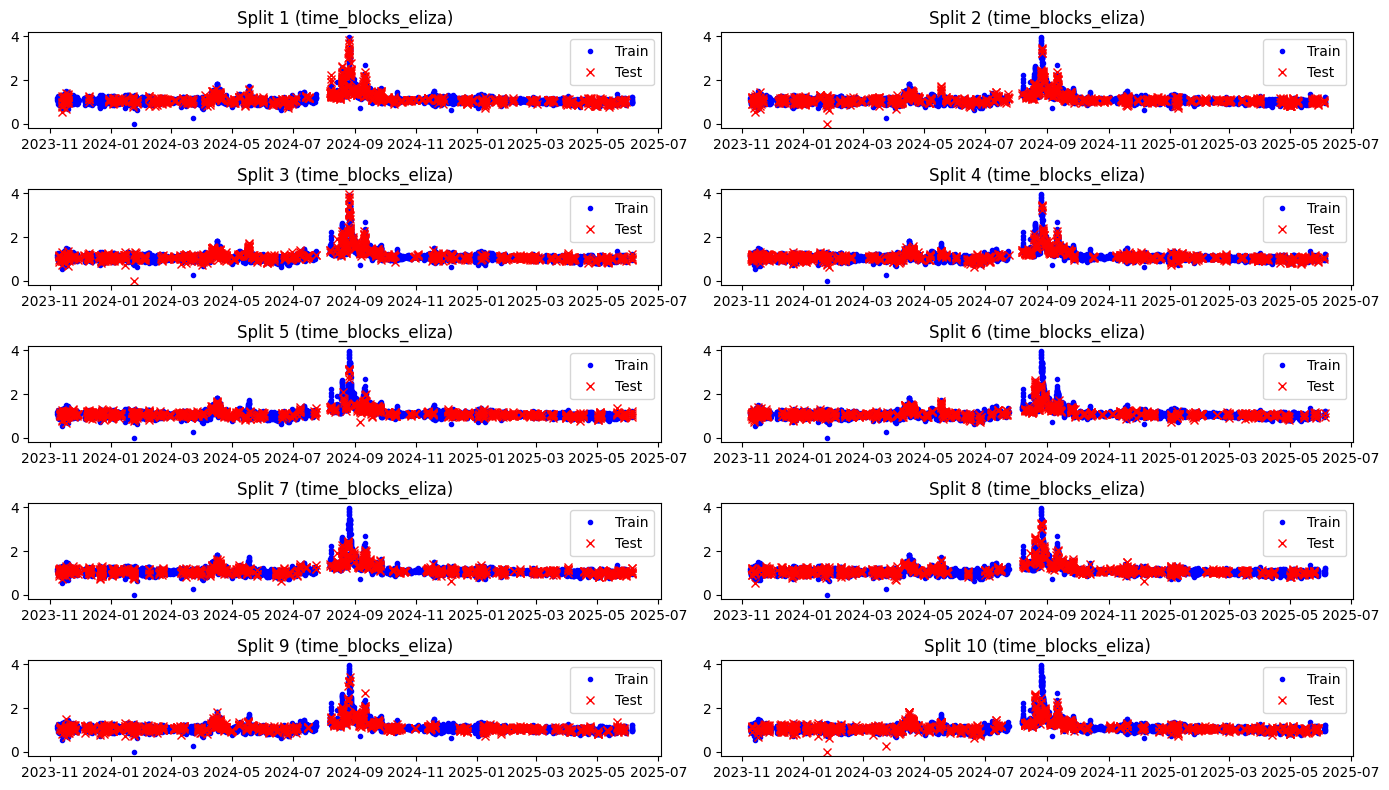

In [9]:
def create_splits(X, y, n_folds, test_size=0.2, random_state=42, n_bins=5):
    """Creates train-test splits using StratifiedShuffleSplit or StratifiedKFold with equal-width binning."""
    
    # Use pd.cut to create equal-width bins (avoids empty bins issue)
    y_binned = pd.cut(y, bins=n_bins, labels=False, include_lowest=True)

    # Select method for stratified splitting
    if CROSSVAL_SPLIT == "shuffle":
        splitter = StratifiedShuffleSplit(n_splits=n_folds, test_size=test_size, random_state=random_state)
    elif CROSSVAL_SPLIT == "kfold":
        splitter = StratifiedKFold(n_splits=n_folds, shuffle=False)

    # Generate train-test splits
    splits = [(train_idx, test_idx) for train_idx, test_idx in splitter.split(X, y_binned)]

    return splits

if CROSSVAL_SPLIT == 'time_blocks_eliza':
    def create_splits(X, y, n_folds, split=0.2, mean_block = 6, min_block=1, random_state=42): # you can set mean block to median_nan_size
        """Generates multiple train-test index splits using block-based cross-validation by varying the random seed."""
        splits = []
        total_test = round(len(X) * split)
        n_blocks = round(total_test/mean_block)

        if mean_block < min_block:
            raise ValueError("Min block size is too large for the number of blocks.")

        for fold in range(n_folds):
            np.random.seed(random_state + fold)  # Change seed for each fold
            
            tt = np.zeros(len(X))  # Array to store train-test assignments

            # Generate random block sizes with normal variation
            blocks = np.array([max(min_block, mean_block + round(v)) 
                            for v in np.random.normal(0, mean_block / 10, n_blocks)])

            # Randomly shuffle the starting positions of test blocks
            available_positions = np.arange(len(X))  # Possible start positions
            np.random.shuffle(available_positions)   # Shuffle them

            # Assign blocks sequentially based on shuffled positions
            assigned = set()
            for b in blocks:
                if len(assigned) >= total_test:
                    break
                # Pick a random starting position
                istart = np.random.choice(available_positions)
                iend = min(istart + int(b), len(X))

                # Ensure blocks don't overlap significantly
                assigned.update(range(istart, iend))
                tt[istart:iend] = 1

            train_idx = np.where(tt == 0)[0]
            test_idx = np.where(tt == 1)[0]
            
            splits.append((train_idx, test_idx))

        return splits


X = data.drop(columns=TARGET)
y = data[TARGET]
# Create the splits using StratifiedShuffleSplit
cross_val_splits = create_splits(X, y, n_folds=N_FOLDS)


# --- PLOT TRAIN-TEST SPLITS ---
n_rows = math.ceil(N_FOLDS / 2)  # Ensure enough rows for all splits
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 8))
axes = axes.flatten()  # Flatten the axes array to make iteration easier

for i, (train_idx, test_idx) in enumerate(cross_val_splits):
    train_idx_mapped = X.iloc[train_idx].index
    test_idx_mapped = X.iloc[test_idx].index

    # Plot train and test points
    axes[i].plot(y.loc[train_idx_mapped].index, y.loc[train_idx_mapped], '.', label='Train', color="blue")
    axes[i].plot(y.loc[test_idx_mapped].index, y.loc[test_idx_mapped], 'x', label='Test', color="red")
    
    axes[i].set_title(f"Split {i + 1} ({CROSSVAL_SPLIT})")
    axes[i].legend()

# Hide unused subplots if n_folds is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# CROSS-VALIDATION

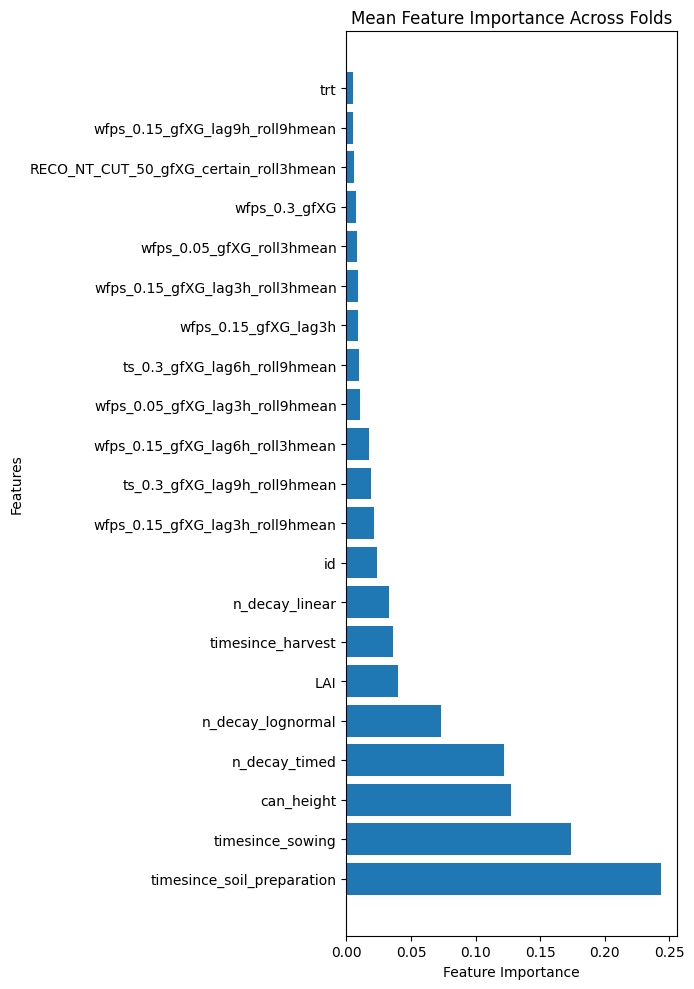

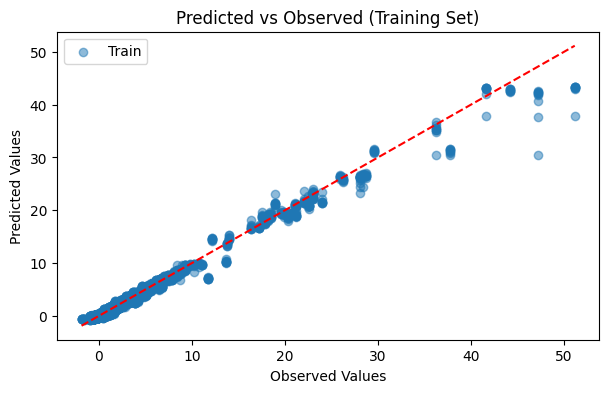

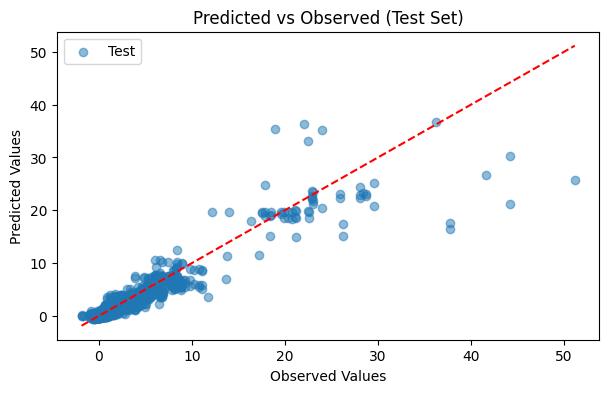

Train RMSE per fold: [0.3444 0.3092 0.3594 0.3087 0.2995 0.309  0.302  0.3117 0.2995 0.3075]
Mean Train RMSE: 0.3151
Test RMSE per fold: [1.409  0.53   1.5194 0.4863 0.4461 0.3931 0.4157 0.5111 0.4948 0.5327]
Mean Test RMSE: 0.6738
Train R² per fold: [0.9752 0.9849 0.9697 0.985  0.9868 0.9865 0.987  0.9843 0.9859 0.9866]
Mean Train R²: 0.9832
Test R² per fold: [0.8296 0.9395 0.8314 0.948  0.9237 0.8849 0.8562 0.9517 0.9464 0.8111]
Mean Test R²: 0.8922


In [10]:
X = data.drop(columns=TARGET)
y = data[TARGET]

# Store results
rmse_train_values, rmse_test_values = [], []
r2_train_values, r2_test_values = [], []
feature_importances_folds = []
y_train_all, y_train_pred_all = [], []
y_test_all, y_pred_test_all = [], []

# Perform cross-validation
for train_idx, test_idx in cross_val_splits:  
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    if LOG_TRANSFORM:
        y_train =  inverse_log_transform(y_train)
        y_test =  inverse_log_transform(y_test)
        y_train_pred =  inverse_log_transform(y_train_pred)
        y_test_pred =  inverse_log_transform(y_test_pred)

    # Store RMSE & R² for training and test sets
    rmse_train_values.append(root_mean_squared_error(y_train, y_train_pred))
    rmse_test_values.append(root_mean_squared_error(y_test, y_test_pred))
    r2_train_values.append(r2_score(y_train, y_train_pred))
    r2_test_values.append(r2_score(y_test, y_test_pred))

    # Store feature importances
    feature_importances_folds.append(model.feature_importances_)

    # Store predictions
    y_train_all.extend(y_train)
    y_train_pred_all.extend(y_train_pred)
    y_test_all.extend(y_test)
    y_pred_test_all.extend(y_test_pred)

# Compute mean feature importance across folds
feature_importances = np.nanmean(feature_importances_folds, axis=0)
# Sort feature importances
order = np.argsort(-feature_importances)  # Sort in descending order
feature_names = X_train.columns[order]  # Get feature names sorted by importance

# Plot sorted feature importances
fig, ax = plt.subplots(figsize=(7, 10))
ax.barh(feature_names, feature_importances[order])
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Features")
ax.set_title("Mean Feature Importance Across Folds")
fig.tight_layout()
plt.show()

# Plot Predicted vs Observed (Training Set)
plt.figure(figsize=(7, 4))
plt.scatter(y_train_all, y_train_pred_all, alpha=0.5, label="Train")
plt.plot([min(y_train_all), max(y_train_all)], [min(y_train_all), max(y_train_all)], color='red', linestyle='--')
plt.xlabel("Observed Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Observed (Training Set)")
plt.legend()
plt.show()

# Plot Predicted vs Observed (Test Set)
plt.figure(figsize=(7, 4))
plt.scatter(y_test_all, y_pred_test_all, alpha=0.5, label="Test")
plt.plot([min(y_test_all), max(y_test_all)], [min(y_test_all), max(y_test_all)], color='red', linestyle='--')
plt.xlabel("Observed Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Observed (Test Set)")
plt.legend()
plt.show()

# Print RMSE and R² for both Training and Test sets
print(f"Train RMSE per fold: {np.array(rmse_train_values).round(4)}")
print(f"Mean Train RMSE: {np.mean(rmse_train_values):.4f}")
print(f"Test RMSE per fold: {np.array(rmse_test_values).round(4)}")
print(f"Mean Test RMSE: {np.mean(rmse_test_values):.4f}")

print(f"Train R² per fold: {np.array(r2_train_values).round(4)}")
print(f"Mean Train R²: {np.mean(r2_train_values):.4f}")
print(f"Test R² per fold: {np.array(r2_test_values).round(4)}")
print(f"Mean Test R²: {np.mean(r2_test_values):.4f}")


# FINAL MODEL

## Split train-test

Block splitting with test blocks that can vary of size and we can define the minimum size

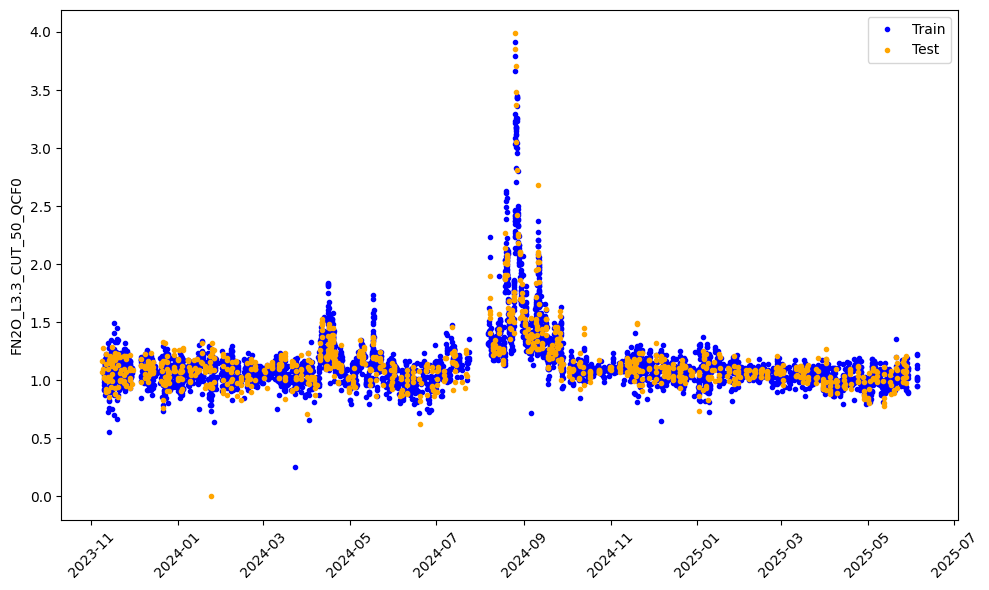

In [11]:
#mean_block = round(mean_nan_size)
mean_block = 6

def split_blocks(X, y, mean_block = mean_block, split=0.2, min_block=1):
       np.random.seed(42)  # Set seed for reproducibility
       tt = np.zeros(len(X)) # space for training/test assignments
       total_test = round(len(X)* split)
       n_blocks = round(total_test/mean_block)
       if mean_block<min_block:
              print("Error: Min block too long for this many blocks")
              return None
       # Vary the length of blocks around the mean (but not below the min)
       blocks = np.array([mean_block + round(v) for v in np.random.normal(0, mean_block/10, n_blocks)])
       blocks[blocks < min_block] = min_block
       # Assign the blocks
       for n, b in enumerate(blocks):
              istart = round(len(X)/(n_blocks))*(n-1)
              iend = istart+b
              tt[istart:iend] = 1
       X_train = X[tt==0]
       X_test = X[tt==1]
       y_train = y[tt==0]
       y_test = y[tt==1]
       # Return sorted data by index (timestamp)
       return X_train.sort_index(), X_test.sort_index(), y_train.sort_index(), y_test.sort_index(), tt

X = data.drop(columns=TARGET)
y = data[TARGET]
X_train, X_test, y_train, y_test, tt = split_blocks(X, y, mean_block=mean_block) # set number of blocks
              
# Check the split
fig, ax = plt.subplots(figsize=(10, 6))  # Adjusted size for better readability
ax.plot(y_train.index, y_train, ".", label="Train", color='blue')
ax.plot(y_test.index, y_test, ".", label="Test", color='orange')
ax.set_ylabel(TARGET)
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()

# Show the plot
plt.show()

## Model training and testing

[0]	validation_0-rmse:0.29643
[1]	validation_0-rmse:0.29396
[2]	validation_0-rmse:0.29157
[3]	validation_0-rmse:0.28940
[4]	validation_0-rmse:0.28712
[5]	validation_0-rmse:0.28486
[6]	validation_0-rmse:0.28273
[7]	validation_0-rmse:0.28059
[8]	validation_0-rmse:0.27839
[9]	validation_0-rmse:0.27615
[10]	validation_0-rmse:0.27397
[11]	validation_0-rmse:0.27185
[12]	validation_0-rmse:0.26974
[13]	validation_0-rmse:0.26761
[14]	validation_0-rmse:0.26574
[15]	validation_0-rmse:0.26374
[16]	validation_0-rmse:0.26167
[17]	validation_0-rmse:0.25983
[18]	validation_0-rmse:0.25784
[19]	validation_0-rmse:0.25602
[20]	validation_0-rmse:0.25411
[21]	validation_0-rmse:0.25220
[22]	validation_0-rmse:0.25035
[23]	validation_0-rmse:0.24844
[24]	validation_0-rmse:0.24734
[25]	validation_0-rmse:0.24554
[26]	validation_0-rmse:0.24375
[27]	validation_0-rmse:0.24216
[28]	validation_0-rmse:0.24051
[29]	validation_0-rmse:0.23873
[30]	validation_0-rmse:0.23699
[31]	validation_0-rmse:0.23539
[32]	validation_0-

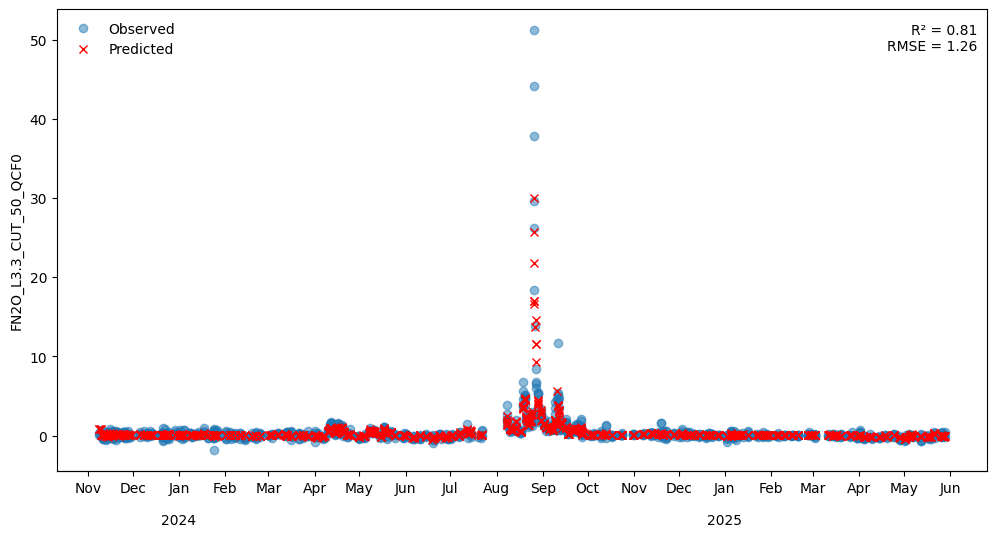

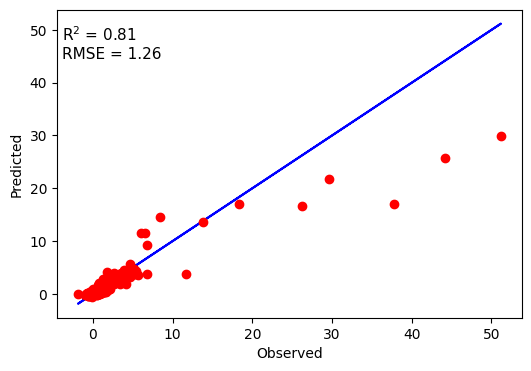

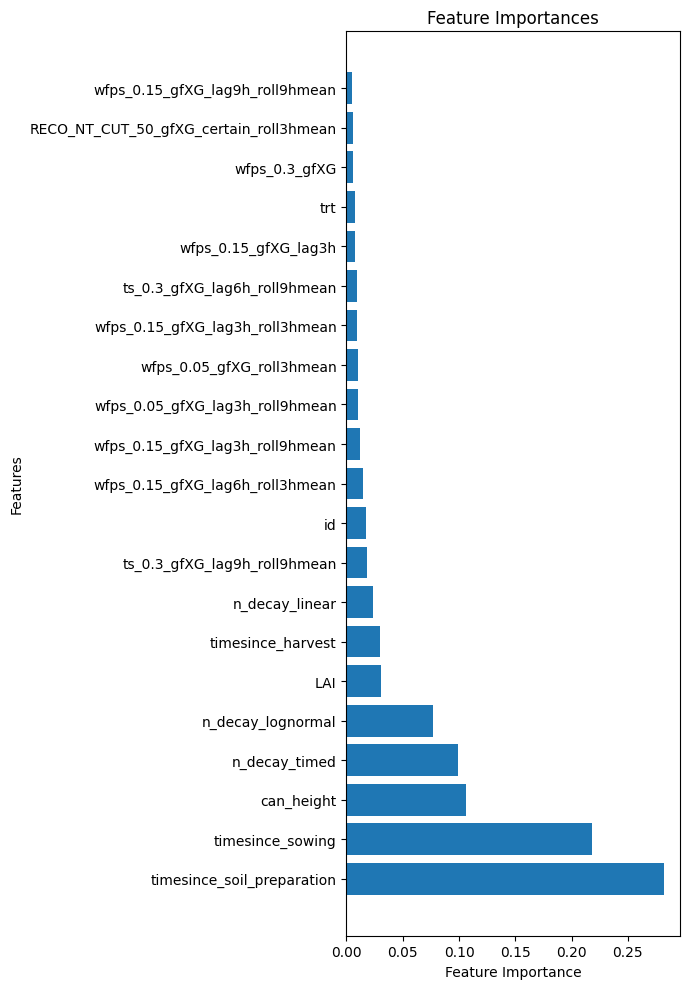

In [12]:
# Use early stopping if using XGBoost
model = RandomForestRegressor(**hyperparams, random_state=42, n_jobs=-1, early_stopping_rounds=10, eval_metric="rmse") if MODEL_TYPE == 'RandomForest' else XGBRegressor(**hyperparams, random_state=42, n_jobs=-1, early_stopping_rounds=10, eval_metric="rmse")

# Predict test set
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=True)
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

# Reverse the log transformation on the predictions and the original transformed data when the transformation was used
if LOG_TRANSFORM:
    pred_train = inverse_log_transform(pred_train) 
    pred_test = inverse_log_transform(pred_test)
    y_train = inverse_log_transform(y_train)
    y_test = inverse_log_transform(y_test)

# Calculate R-squared and Mean Squared Error (MSE) for the training set
r2_train = r2_score(y_train, pred_train)
print(f"R-squared (Training set): {r2_train:.4f}")
rmse_train = root_mean_squared_error(y_train, pred_train)
print(f"Root Mean Squared Error (Training set): {rmse_train:.4f}")
# Calculate R-squared and Mean Squared Error (MSE) for the test set
r2_test = r2_score(y_test, pred_test)
print(f"R-squared (Test set): {r2_test:.4f}")
rmse_test = root_mean_squared_error(y_test, pred_test)
print(f"Root Mean Squared Error (Test set): {rmse_test:.4f}")

# Time series plot
fig, ax = plt.subplots(1,figsize=(12, 6))
ax.plot(y_test.index, y_test,"o",label=("Observed"), alpha=0.5)
ax.plot(y_test.index, pred_test,"rx",label=("Predicted"))
# Format x-axis for months
ax.xaxis.set_major_locator(mdates.MonthLocator())  # Major ticks for months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as month abbreviation
# Add secondary x-axis for years
secax = ax.secondary_xaxis('bottom')
secax.xaxis.set_major_locator(mdates.YearLocator())  # Year ticks
secax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format as year
secax.tick_params(axis='x', length=0, pad=30)  # Add padding for better readability
# Add R2 and RMSE text
ax.text(0.99, 0.97, f'R² = {r2_test:.2f}\nRMSE = {rmse_test:.2f}',
        transform=ax.transAxes, va='top', ha='right')
ax.set_ylabel(TARGET)
ax.legend(frameon=False, loc="upper left")
# save fig
plt.savefig(f'plots/{TARGET}_gapfilling_testset_performance.png', dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Obs Vs predicted
fig, ax = plt.subplots(1,figsize=(6,4))
ax.plot(y_test,y_test,"b-")
ax.plot(y_test,pred_test,"ro")
# Add R2 and RMSE text
ax.text(0.01, 0.95, f'R$^{2}$ = {r2_test:.2f}\nRMSE = {rmse_test:.2f}',
        transform=ax.transAxes, va='top', fontsize=11)
ax.set_xlabel("Observed")
ax.set_ylabel("Predicted")
plt.show()

# Plot feature importances
importances = model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]  # Sort descending
feature_names_sorted = X_train.columns[sorted_idx]

fig, ax = plt.subplots(figsize=(7, 10))
ax.barh(feature_names_sorted, importances[sorted_idx])
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Features")
ax.set_title("Feature Importances")
plt.tight_layout()
plt.show()

# SHAP ANALYSIS

## RUN SHAP

In [ ]:
# define background dataset
background_dataset = data_main[selected_features]

# Initialize the SHAP explainer
explainer = shap.TreeExplainer(model, data=background_dataset)

# Calculate SHAP values for the entire dataset
X = data_main[selected_features]
shap_values = explainer(X, check_additivity=True)

# Print the expected value
print("Baseline (expected value):", explainer.expected_value)
if LOG_TRANSFORM:
    print("Baseline without transformation (expected value):", inverse_log_transform(explainer.expected_value))

## SUMMARY PLOT

In [ ]:
# SHAP summary plot
fig = plt.figure()
shap.summary_plot(shap_values, X, show=False)
# Save the figure
fig.savefig(f'plots/{TARGET}_shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## SHAP SCATTERPLOTS

In [ ]:
# Dependence plots

for var in X.columns:
    shap.plots.scatter(shap_values[:, var], dot_size=3, x_jitter=0.5, color=shap_values)
#    shap.dependence_plot(var, shap_values.values, X)
    plt.show()

# GAP-FILLING

In [18]:
QCF = 'QCF0'
GAPFILLING_TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_{QCF}'

# Prepare empty columns in master dataframe
for letter in ["A", "B"]:
    mask = data_main["parcel"] == letter
    data_main[f"{GAPFILLING_TARGET}_parcel{letter}"] = np.where(mask, data_main[GAPFILLING_TARGET], np.nan)
    data_main[f"{GAPFILLING_TARGET}_{MODEL_TYPE}_pred_parcel{letter}"] = np.nan
    data_main[f"{GAPFILLING_TARGET}_gf{MODEL_TYPE}_parcel{letter}_all"] = np.nan
    data_main[f"{GAPFILLING_TARGET}_gf{MODEL_TYPE}_parcel{letter}_certain"] = np.nan

# Add parcel specific cols if there are any
def add_parcel_specific(sf, cols):
    out, seen = [], set()
    for c in sf:
        cand = [c] if "_parcel" in c else ([x for x in cols if x.startswith(f"{c}_parcel")] or ([c] if c in cols else []))
        for x in cand:
            if x not in seen: out.append(x); seen.add(x)
    return out

features = add_parcel_specific(selected_features, list(data_main.columns))

# Gapfill each parcel
def predict_for_parcel(letter):
    base = [c for c in features if 'parcel' not in c]
    side = [c for c in features if f'parcel{letter}' in c]
    sel  = base + side
    X = data_main[sel].copy()
    X.columns = X.columns.str.replace(f'_parcel{letter}', '', regex=False)
    X = X[selected_features] # correct order of columns
    if ADD_TRT:
        X['trt'] = 0 if letter == 'A' else (1 if letter == 'B' else 0.5)
    yhat = model.predict(X).astype(np.float64)
    return inverse_log_transform(yhat) if LOG_TRANSFORM else yhat

for letter in ['A','B']:
    yhat = predict_for_parcel(letter)

    # columns to write
    col_certain = f'{GAPFILLING_TARGET}_gf{MODEL_TYPE}_parcel{letter}_certain'
    col_all     = f'{GAPFILLING_TARGET}_gf{MODEL_TYPE}_parcel{letter}_all'
    col_predicted = f'{GAPFILLING_TARGET}_{MODEL_TYPE}_pred_parcel{letter}'

    # start with predictions everywhere
    data_main[col_certain] = yhat
    data_main[col_all]     = yhat
    data_main[col_predicted] = yhat

    # masks
    m_all     = (data_main['parcel'] == letter) & (data_main[GAPFILLING_TARGET].notna())
    m_certain = m_all & (data_main['parcel_certainty'] == 'certain')

    # overwrite with observed target
    data_main.loc[m_certain, col_certain] = data_main.loc[m_certain, GAPFILLING_TARGET]
    data_main.loc[m_all,     col_all]     = data_main.loc[m_all,     GAPFILLING_TARGET]

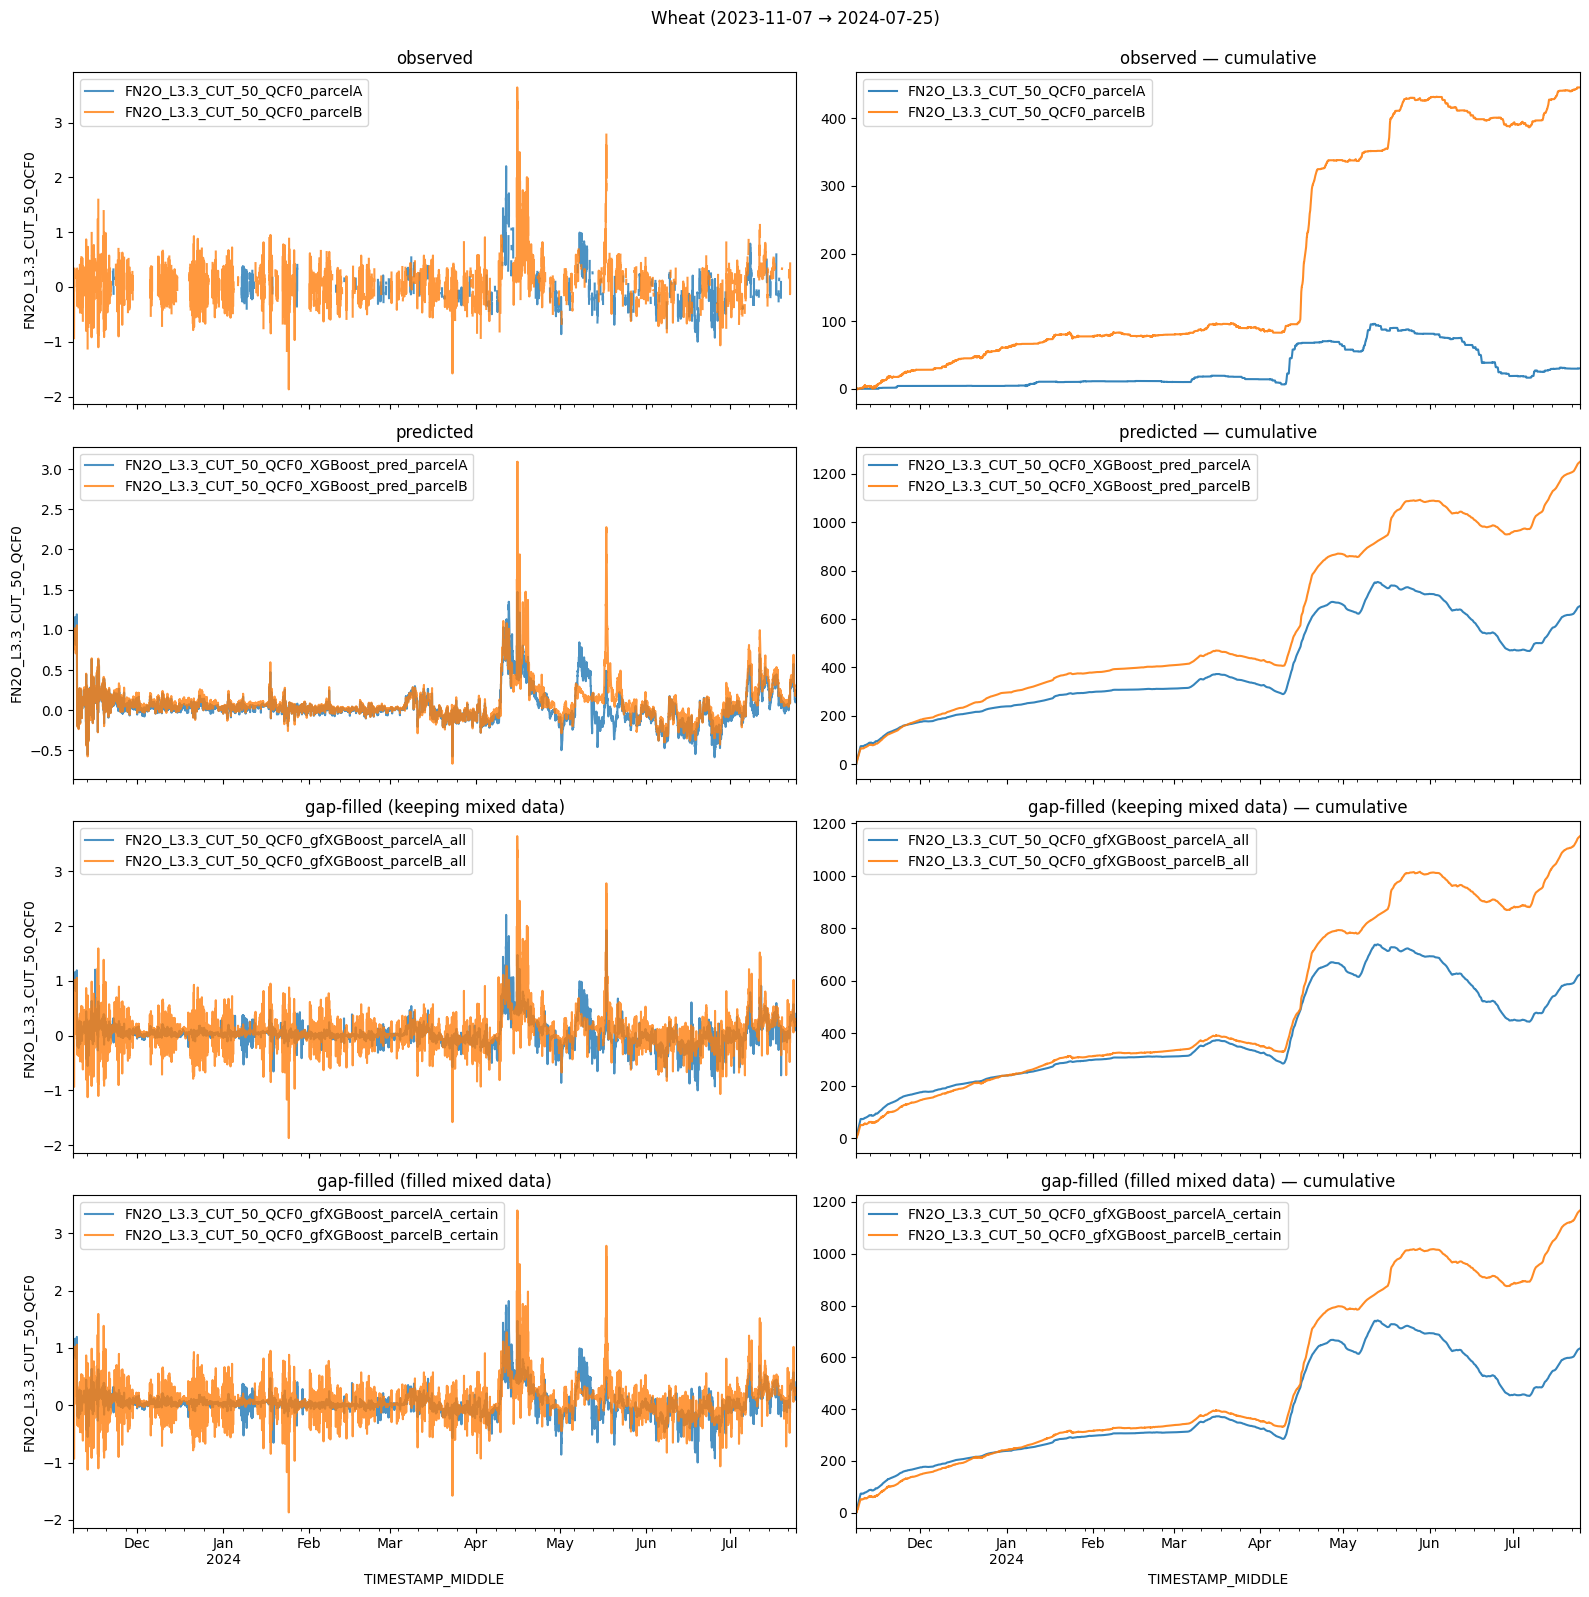

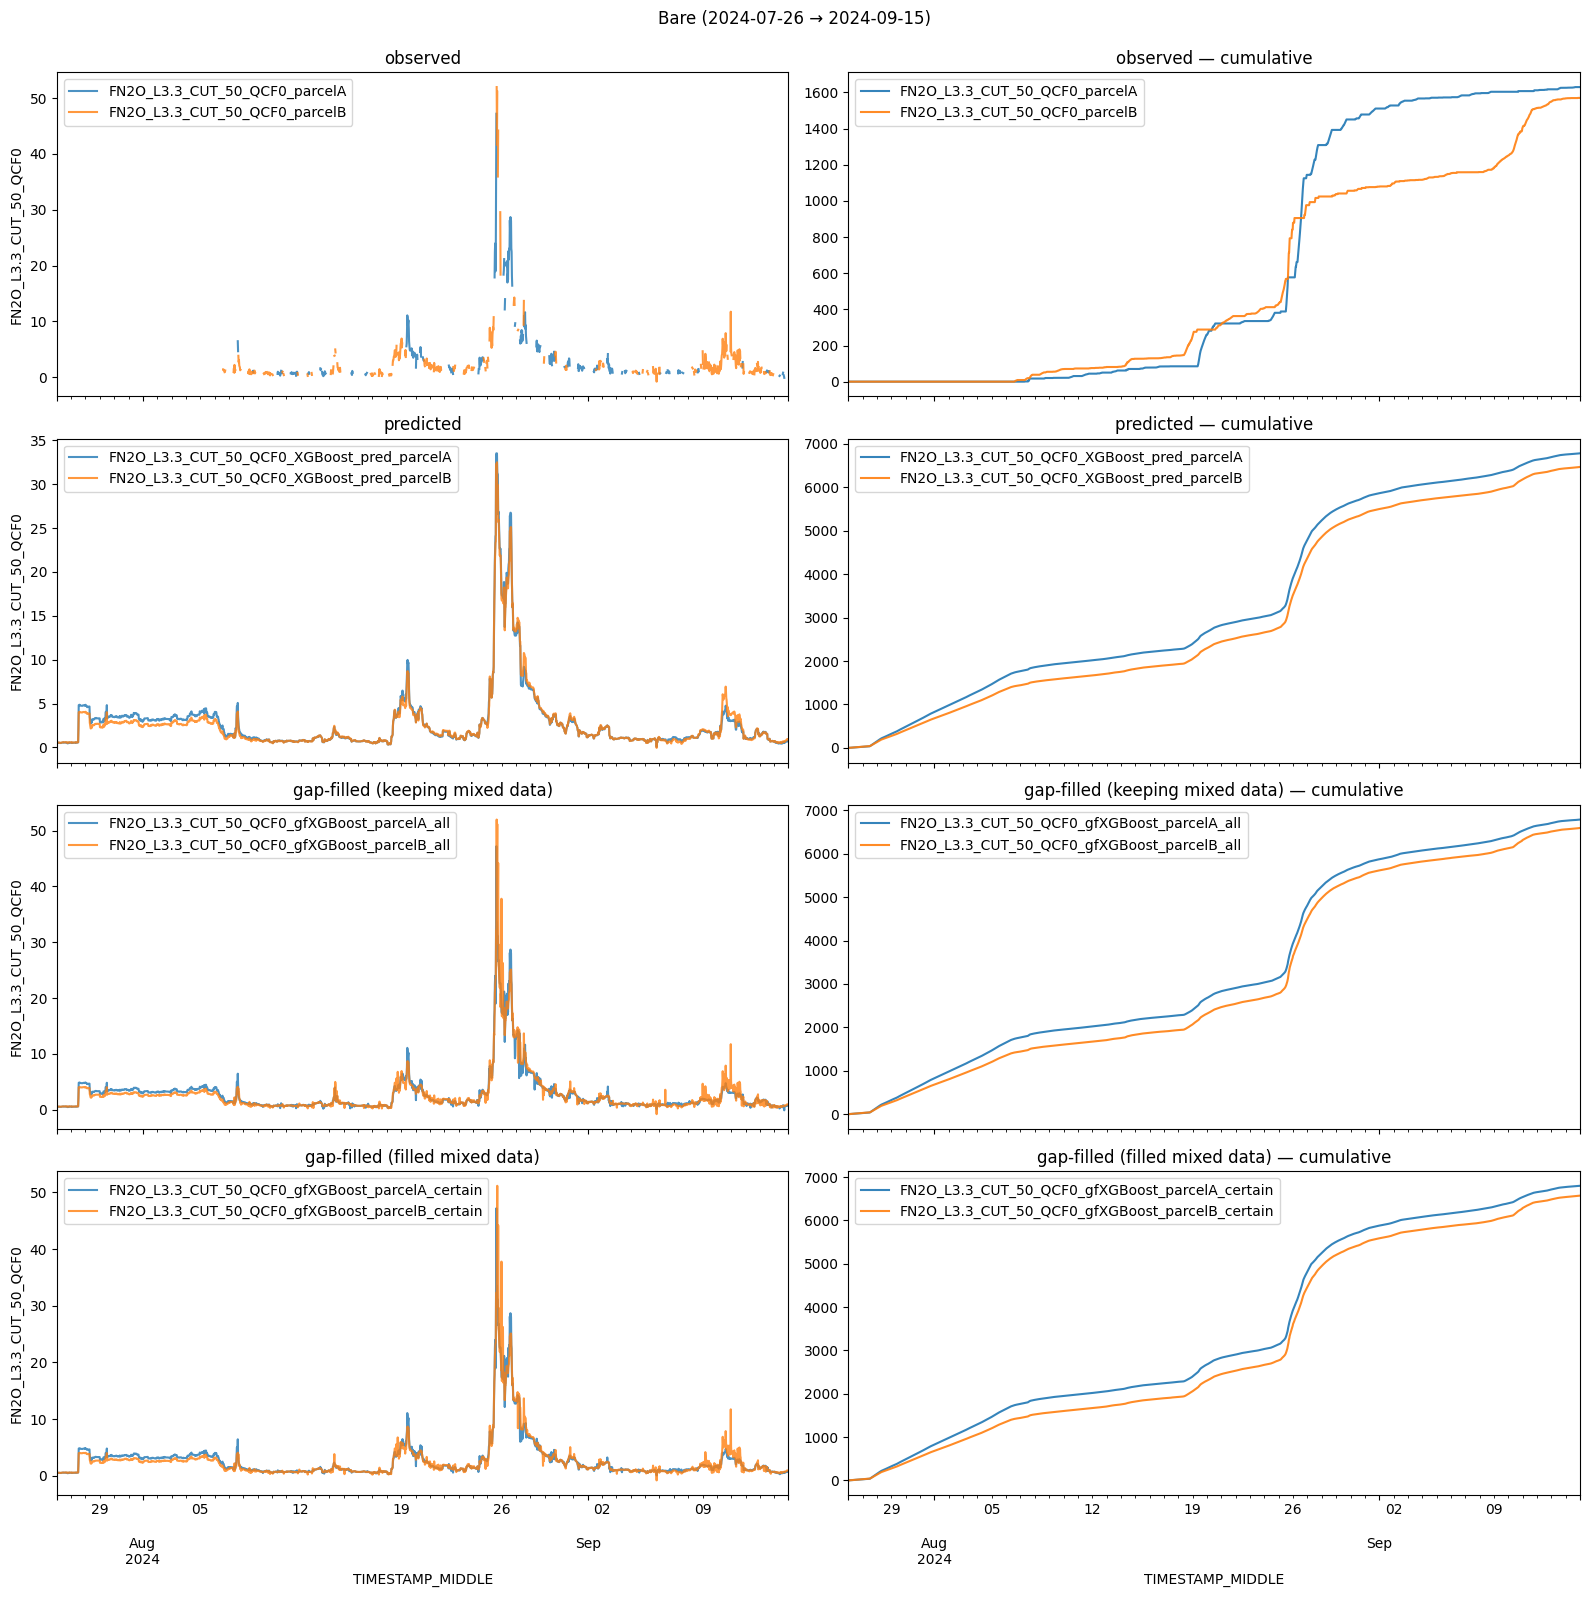

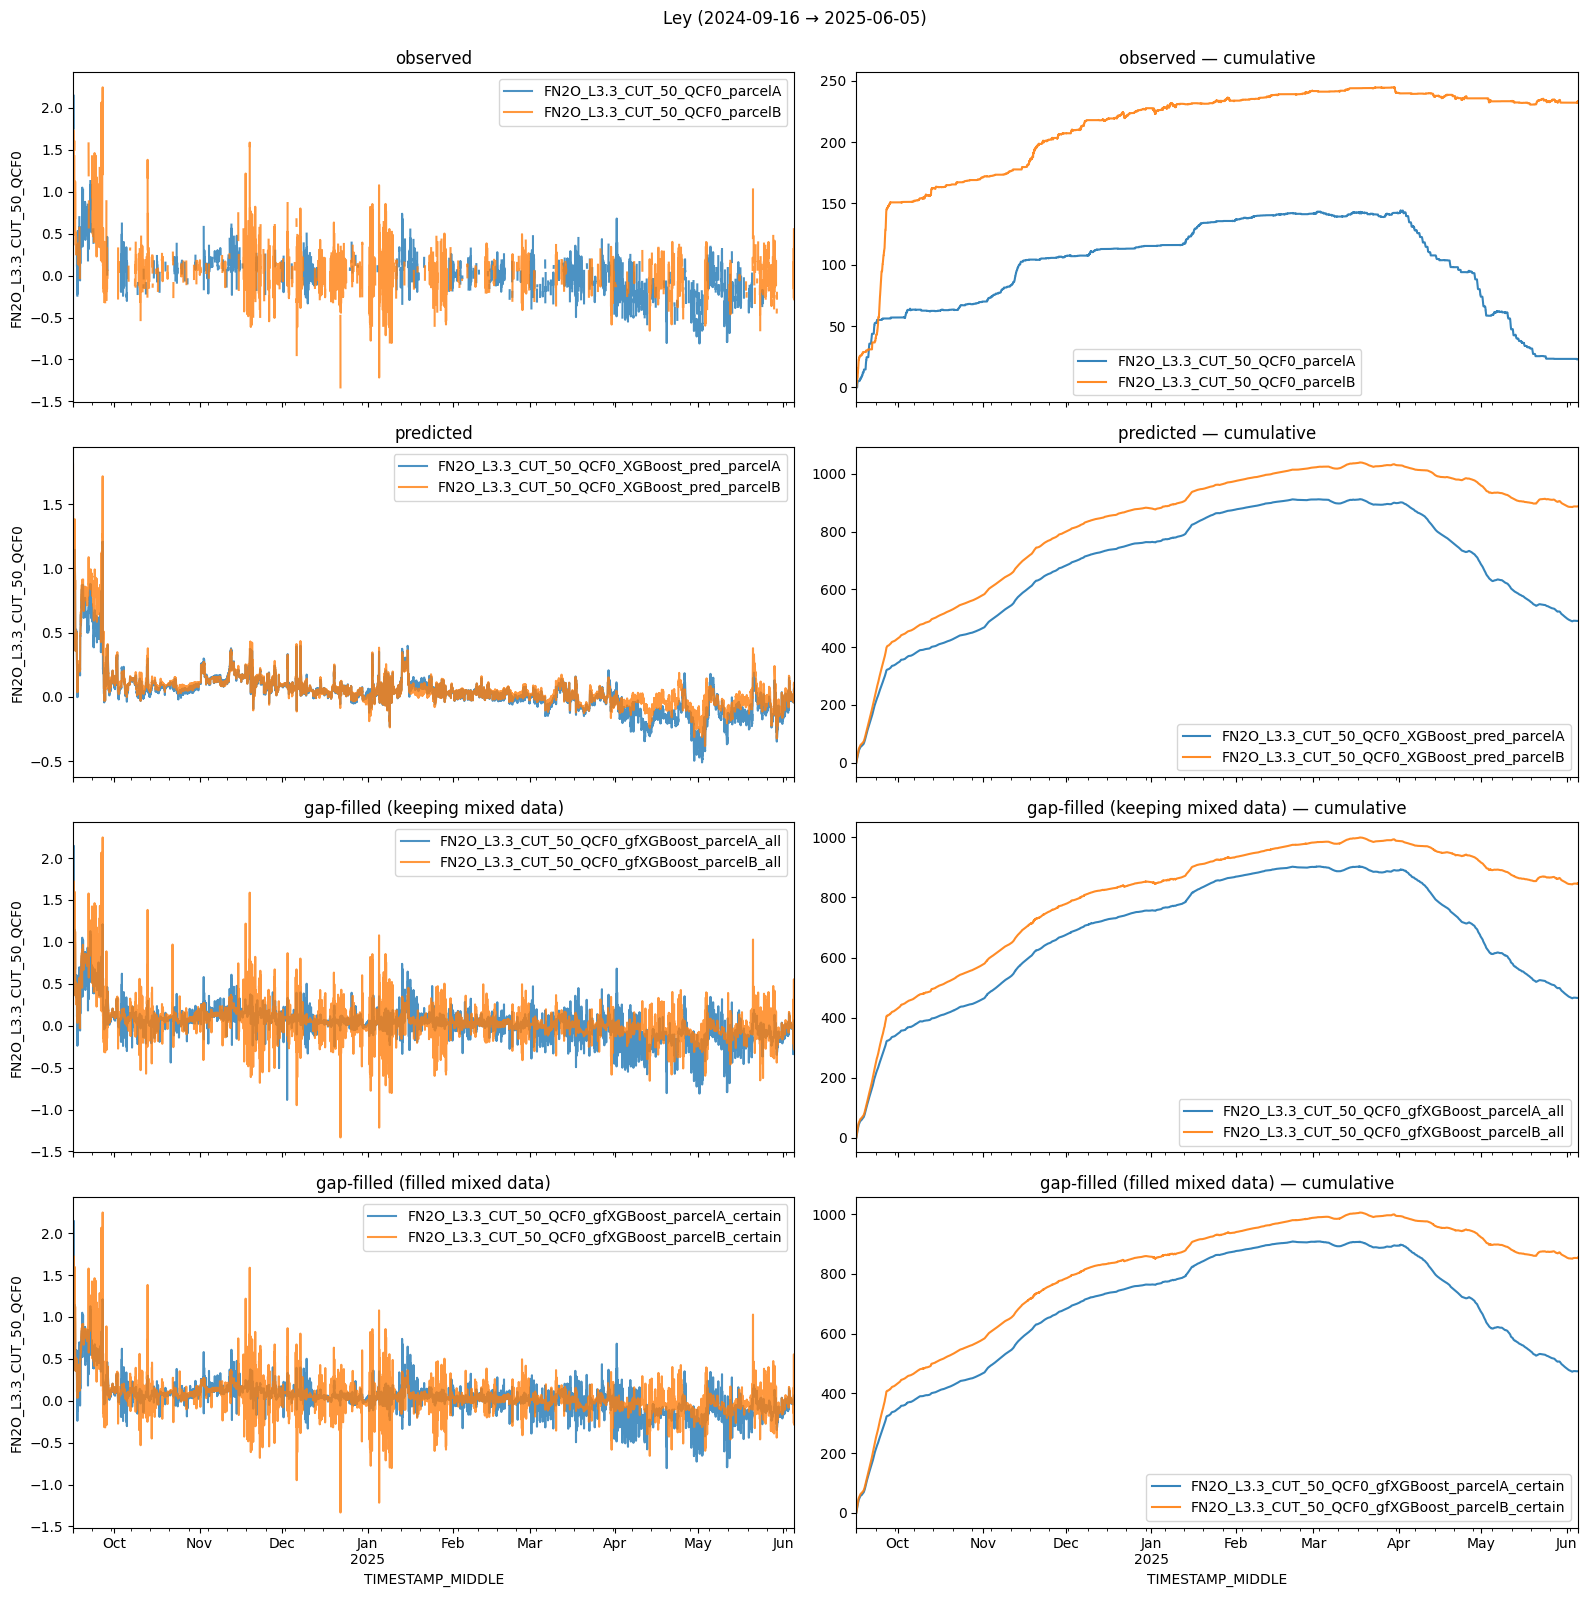

In [19]:
# Plots

# Define periods
periods = [
    ("2023-11-07", "2024-07-25", "Wheat"),
    ("2024-07-26", "2024-09-15", "Bare"),
    ("2024-09-16", "2025-06-05", "Ley"),
]

# periods = [
#     ("2024-02-07", "2024-02-10", "Wheat"),
#     ("2024-08-01", "2024-08-04", "Bare"),
#     ("2025-03-16", "2025-03-29", "Ley"),
# ]

for start, end, label in periods:
    period_df = data_main.loc[pd.to_datetime(start):pd.to_datetime(end)]
    PARCELS = ['A', 'B']
    pairs = [
        ([f"{GAPFILLING_TARGET}_parcel{p}" for p in PARCELS], "observed"),
        ([f"{GAPFILLING_TARGET}_{MODEL_TYPE}_pred_parcel{p}" for p in PARCELS], "predicted"),
        ([f"{GAPFILLING_TARGET}_gf{MODEL_TYPE}_parcel{p}_all" for p in PARCELS], "gap-filled (keeping mixed data)"),
        ([f"{GAPFILLING_TARGET}_gf{MODEL_TYPE}_parcel{p}_certain" for p in PARCELS], "gap-filled (filled mixed data)"),
    ]

    # Keep only existing columns
    pairs = [(cols, t) for cols, t in pairs if all(c in period_df.columns for c in cols)]
    if not pairs: 
        continue

    nrows, ncols = len(pairs), 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4*nrows), sharex='col')
    if nrows == 1:  # make indexing uniform
        axes = axes.reshape(1, ncols)

    for r, (cols, t) in enumerate(pairs):
        # raw
        period_df[cols].plot(ax=axes[r, 0], alpha=0.8)
        axes[r, 0].set_title(f"{t}")
        axes[r, 0].set_ylabel(GAPFILLING_TARGET)

        # cumulative
        cumulative = period_df[cols].fillna(0).cumsum()
        cumulative.plot(ax=axes[r, 1], alpha=0.9)
        axes[r, 1].set_title(f"{t} — cumulative")

    fig.suptitle(f"{label} ({start} → {end})", y=0.995, fontsize=12)
    plt.tight_layout()
    plt.show()

# EXPORT

In [20]:
newcols = [c for c in data_main.columns if c not in maindf if f'gf{MODEL_TYPE}' in c]
print(f"NEW VARIABLES FROM GAP-FILLING {TARGET_FLUX}:")
for c in newcols:
    print(f"+ {c}")

NEW VARIABLES FROM GAP-FILLING FN2O:
+ FN2O_L3.3_CUT_50_QCF_gfXGBoost_parcelA_all
+ FN2O_L3.3_CUT_50_QCF_gfXGBoost_parcelA_certain
+ FN2O_L3.3_CUT_50_QCF_gfXGBoost_parcelB_all
+ FN2O_L3.3_CUT_50_QCF_gfXGBoost_parcelB_certain
+ FN2O_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_all
+ FN2O_L3.3_CUT_50_QCF0_gfXGBoost_parcelA_certain
+ FN2O_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_all
+ FN2O_L3.3_CUT_50_QCF0_gfXGBoost_parcelB_certain


In [21]:
filename = f"82.4.1_{TARGET_FLUX}_GF-{MODEL_TYPE}"
df_export = data_main[newcols]
df_export.to_csv(f"{filename}.csv", index=True)

# End of notebook

In [22]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-10-08 19:28:51
